<a href="https://colab.research.google.com/github/remixwithkj/Backupmac/blob/main/pca_visualization_2d_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction using PCA and Visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data_file = "https://raw.githubusercontent.com/manaranjanp/ISB_MLUL/main/clustering/beer.csv"

In [ ]:
beer_df = pd.read_csv(data_file)

In [ ]:
beer_df

,name,calories,sodium,alcohol,cost
0,Budweiser,144,15,4.7,0.43
1,Schlitz,151,19,4.9,0.43
2,Kronenbourg,170,7,5.2,0.73
3,Heineken,152,11,5.0,0.77
4,Old_Milwaukee,145,23,4.6,0.28
5,Augsberger,175,24,5.5,0.40
6,Srohs_Bohemian_Style,149,27,4.7,0.42
7,Miller_Lite,99,10,4.3,0.43
8,Budweiser_Light,113,8,3.7,0.40
9,Coors,140,18,4.6,0.44


In [ ]:
beer_df.columns

Index(['name', 'calories', 'sodium', 'alcohol', 'cost'], dtype='object')

In [ ]:
features = ['calories', 'sodium', 'alcohol', 'cost']

## Apply PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
# pca = PCA()
pca = PCA(n_components=2)

In [ ]:
pca.fit(beer_df[features])

PCA(n_components=2)

In [ ]:
beer_2d = pca.transform(beer_df[features])

In [ ]:
beer_2d.shape

(19, 2)

### Explained Variance

In [ ]:
pca.explained_variance_ratio_

array([0.96188794, 0.03800928])

pca.explained_variance_ratio_: This attribute of the fitted pca object stores the explained variance ratio for each principal component. The explained variance ratio represents the proportion of the total variance in the original data that is explained by each principal component. In simpler terms, it tells you how much information each component captures.

np.round(_, 2): This part uses the np.round function from the NumPy library (np) to round the values in pca.explained_variance_ratio_ to 2 decimal places. This is done for better readability and presentation of the results.

In [ ]:
np.round(pca.explained_variance_ratio_, 2)

array([0.96, 0.04])

### Principal Components

In [ ]:
pca.components_

array([[ 0.99502098,  0.0969408 ,  0.02309165,  0.00158295],
       [-0.096667  ,  0.99513078, -0.01118575, -0.01565585]])

In [ ]:
pca.components_.shape

(2, 4)

In [ ]:
beer_2d_df = pd.DataFrame(beer_2d, columns = ['D1', 'D2'])

In [ ]:
beer_2d_df

,D1,D2
0,12.684987,-1.181014
1,20.042515,2.120603
2,37.792027,-11.665692
3,20.264857,-5.943552
4,14.452988,6.686832
5,44.421530,4.770007
6,18.823365,10.277377
7,-32.584898,-1.802179
8,-18.862388,-5.138597
9,8.993432,2.192008


## Visualization

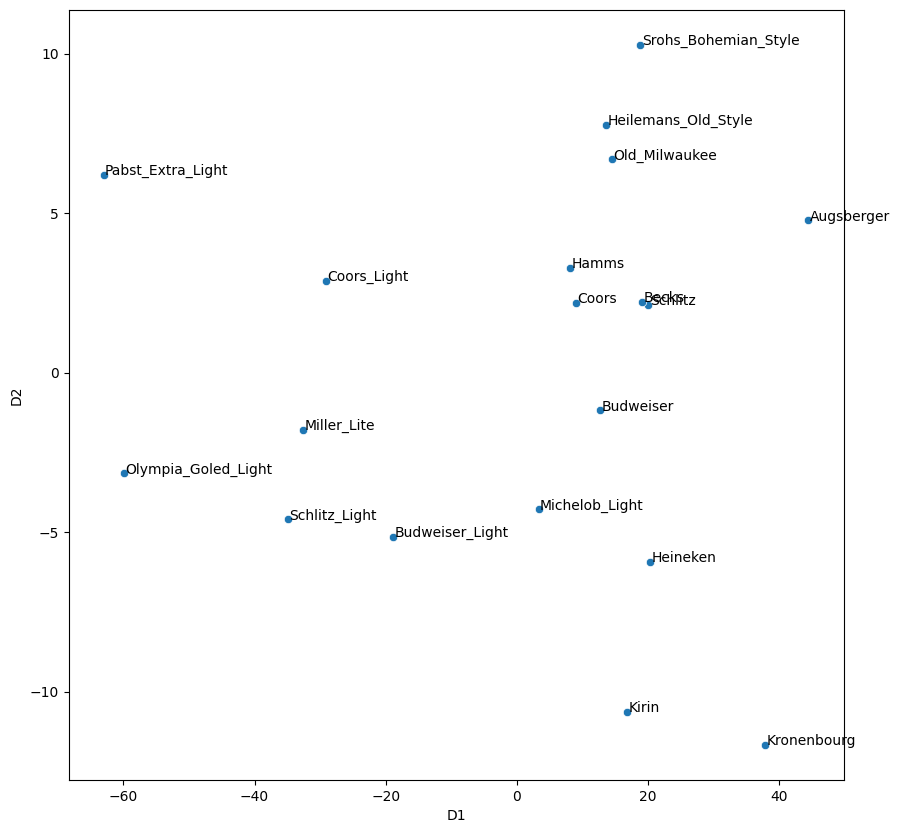

In [ ]:
plt.figure(figsize=(10, 10))
sn.scatterplot(data = beer_2d_df,
               x = 'D1',
               y = 'D2');

beer_df

# add annotations one by one with a loop
for line in range( 0, beer_df.shape[0] ):
     plt.text(beer_2d_df.D1[line]+0.2,
              beer_2d_df.D2[line],
              beer_df.name[line],
              horizontalalignment='left',
              size='medium',
              color='black')

plt.show()